# Notebook 02 — Structure économique et relations entre genres

## Objectif du notebook

Ce notebook constitue la **seconde étape du projet**.  
Après avoir décrit la **structure du catalogue Steam** dans le Notebook 01, l’objectif est ici d’approfondir l’analyse en étudiant :

- les **relations entre genres**
- la **structure économique du catalogue** (prix et promotions)
- certains indicateurs de **réception des jeux par les joueurs**

L’analyse commence par examiner **la manière dont les genres se combinent entre eux**. En effet, un même jeu peut appartenir à plusieurs genres, ce qui signifie que les fréquences individuelles observées dans le Notebook 01 ne suffisent pas à décrire la structure réelle du catalogue.

Une analyse des **cooccurrences entre genres** permet ainsi d’identifier les combinaisons les plus fréquentes et de mieux comprendre les principales structures de gameplay présentes sur la plateforme.

## Dataset utilisé

Le dataset utilisé est le même que dans le Notebook 01 :

s3://full-stack-bigdata-datasets/Big_Data/Project_Steam/steam_game_output.json

Les données sont rechargées et certaines transformations sont reproduites afin de rendre ce notebook **exécutable indépendamment du Notebook 01**.

## Étapes du notebook

Les principales étapes de ce notebook sont les suivantes :

1. Rechargement du dataset et reconstruction des variables nécessaires
2. Analyse des **relations entre genres** (cooccurrences et associations)
3. Étude de la **structure des prix et des promotions**
4. Analyse de certains indicateurs de **réception des jeux** (reviews et scores)
5. Discussion des **limites de l’analyse**

Ces analyses permettent d’apporter une lecture plus approfondie du catalogue Steam en complétant l’analyse descriptive réalisée dans le **Notebook 01**.

# 1. Préparation des données

### 1.1 Chargement des données

In [0]:
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.utils import IllegalArgumentException
from pyspark.sql.functions import col, map_from_arrays, array, lit, explode
from pyspark.sql.functions import count
from pyspark.sql.window import Window
import math
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [0]:
spark

In [0]:
df = spark.read.json(
"s3://full-stack-bigdata-datasets/Big_Data/Project_Steam/steam_game_output.json"
)

In [0]:
df.printSchema()

root
 |-- data: struct (nullable = true)
 |    |-- appid: long (nullable = true)
 |    |-- categories: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- ccu: long (nullable = true)
 |    |-- developer: string (nullable = true)
 |    |-- discount: string (nullable = true)
 |    |-- genre: string (nullable = true)
 |    |-- header_image: string (nullable = true)
 |    |-- initialprice: string (nullable = true)
 |    |-- languages: string (nullable = true)
 |    |-- name: string (nullable = true)
 |    |-- negative: long (nullable = true)
 |    |-- owners: string (nullable = true)
 |    |-- platforms: struct (nullable = true)
 |    |    |-- linux: boolean (nullable = true)
 |    |    |-- mac: boolean (nullable = true)
 |    |    |-- windows: boolean (nullable = true)
 |    |-- positive: long (nullable = true)
 |    |-- price: string (nullable = true)
 |    |-- publisher: string (nullable = true)
 |    |-- release_date: string (nullable = true)
 |    |-

### 1.2 Flatten du champ "data"

Les données sont contenues dans une structure "data". Nous aplatissons donc le dataframe en extrayant toutes les données de "Data" et en supprimant ce niveau.

In [0]:
# Flattening the DataFrame
df = df.select("*", "data.*").drop("data")
# print the schema of the flattened DataFrame
df.printSchema()

root
 |-- id: string (nullable = true)
 |-- appid: long (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- ccu: long (nullable = true)
 |-- developer: string (nullable = true)
 |-- discount: string (nullable = true)
 |-- genre: string (nullable = true)
 |-- header_image: string (nullable = true)
 |-- initialprice: string (nullable = true)
 |-- languages: string (nullable = true)
 |-- name: string (nullable = true)
 |-- negative: long (nullable = true)
 |-- owners: string (nullable = true)
 |-- platforms: struct (nullable = true)
 |    |-- linux: boolean (nullable = true)
 |    |-- mac: boolean (nullable = true)
 |    |-- windows: boolean (nullable = true)
 |-- positive: long (nullable = true)
 |-- price: string (nullable = true)
 |-- publisher: string (nullable = true)
 |-- release_date: string (nullable = true)
 |-- required_age: string (nullable = true)
 |-- short_description: string (nullable = true)
 |-- tags: struct (nul

### 1.3 Nettoyage et création des variables _dérivées_

Suppression du type "Hardware"

In [0]:
df = df.filter(F.col('type') != 'hardware')

#### 1.4 Nettoyage des types des colonnes et ajout de variables

In [0]:

#initialprice
df = df.withColumn(
    "initialprice_eur",
    F.col("initialprice").cast("double") / 100
)

#price
df = df.withColumn(
    "price_eur",
    F.col("price").cast("double") / 100
)

#required_age
df = df.withColumn(
    "required_age_num",
    F.regexp_extract(F.col("required_age"), r"\d+", 0).cast("int")
)

#jeux adultes
df = df.withColumn(
    "is_adult_game",
    F.col("required_age_num") >= 18
)

#owners : c'est initialement un intervalle du nombre min et max de personnes possédant le jeu. On commence par nettoyer la colonne puis on calcul un nombre moyen de propriétaires (min+max)/2.
df = (df
    .withColumn("owners_clean", F.regexp_replace(F.col("owners"), r"\s", ""))
    .withColumn("owners_min",   F.regexp_extract(F.col("owners_clean"), r"^([\d,]+)\.\.", 1))
    .withColumn("owners_max",   F.regexp_extract(F.col("owners_clean"), r"\.\.([\d,]+)$", 1))
    .withColumn("owners_min",   F.regexp_replace(F.col("owners_min"), r",", "").cast("long"))
    .withColumn("owners_max",   F.regexp_replace(F.col("owners_max"), r",", "").cast("long"))
    .withColumn("owners_avg",   F.when(F.col("owners_min").isNotNull() & F.col("owners_max").isNotNull(),((F.col("owners_min") + F.col("owners_max"))/2).cast("double")))
)

#release_date
df = (
    df.withColumn(
        "release_date_dt",
        F.coalesce(
            F.try_to_date("release_date", "MMM d, yyyy"),
            F.try_to_date("release_date", "MMM dd, yyyy"),
            F.try_to_date("release_date", "yyyy-MM-dd"),
            F.try_to_date("release_date", "yyyy/M/d"),
            F.try_to_date("release_date", "yyyy/MM/dd"),

            # format yyyy/MM -> on ajoute /01
            F.try_to_date(F.concat(F.col("release_date"), F.lit("/01")), "yyyy/MM/dd")
        )
    )
    .withColumn("release_year", F.year("release_date_dt"))
    .withColumn("release_month", F.month("release_date_dt"))
)
#reviews : ajout d'un ratio d'avis positifs et d'un score
df = (df
    .withColumn("reviews_total", (F.coalesce(F.col("positive"), F.lit(0)) + F.coalesce(F.col("negative"), F.lit(0))).cast("long"))
    .withColumn(
        "pos_ratio",
        F.when(F.col("reviews_total") > 0, (F.col("positive") / F.col("reviews_total")).cast("double"))
    )
    .withColumn(
        "steam_score",
        F.when(F.col("reviews_total") > 0, (F.col("pos_ratio") * 100).cast("double"))
    )
)

# 2. Création des dataframes auxiliaires

### 2.1 table des tags

In [0]:
tags_fields = df.schema["tags"].dataType.names
print(len(tags_fields))
print(tags_fields[:20])

441
['1980s', "1990's", '2.5D', '2D', '2D Fighter', '2D Platformer', '360 Video', '3D', '3D Fighter', '3D Platformer', '3D Vision', '4 Player Local', '4X', '6DOF', '8-bit Music', 'ATV', 'Abstract', 'Action', 'Action RPG', 'Action RTS']


In [0]:
tags_cols = df.schema["tags"].dataType.names

df_map = df.withColumn(
    "tags_map",
    map_from_arrays(
        array(*[lit(c) for c in tags_cols]),
        array(*[col(f"tags.`{c}`") for c in tags_cols])
    )
)

df_long = df_map.select(
    "appid",
    explode("tags_map").alias("tag", "value")
)
df_long = df_long.filter(col("value").isNotNull() & (col("value") > 0))

top_tags = (
    df_long
    .groupBy("tag")
    .agg(count("*").alias("occurrences"))
    .orderBy(col("occurrences").desc())
)

In [0]:
tag_cols = df.select("tags.*").columns

df_tags = (
    df.select(
        "appid",
        F.explode(
            F.array([
                F.struct(
                    F.lit(c).alias("tag"),
                    F.col(f"tags.`{c}`").alias("occurrences")
                )
                for c in tag_cols
            ])
        ).alias("tag_struct")
    )
    .select(
        "appid",
        F.col("tag_struct.tag"),
        F.col("tag_struct.occurrences")
    )
    .filter(F.col("occurrences") > 0)
)

In [0]:
print("Structure du dataframe df_tags :")
df_tags.printSchema()

Structure du dataframe df_tags :
root
 |-- appid: long (nullable = true)
 |-- tag: string (nullable = false)
 |-- occurrences: long (nullable = true)



### 2.2 table des plateformes

In [0]:
df_platforms = (
    df.select(
        "appid",
        F.col("platforms.windows").alias("Windows"),
        F.col("platforms.mac").alias("Mac"),
        F.col("platforms.linux").alias("Linux"),
    )
)

print("Structure du dataframe df_platforms :")
df_platforms.printSchema()

Structure du dataframe df_platforms :
root
 |-- appid: long (nullable = true)
 |-- Windows: boolean (nullable = true)
 |-- Mac: boolean (nullable = true)
 |-- Linux: boolean (nullable = true)



### 2.3 table des catégories

In [0]:
df_categories = (
    df
    .select("appid", F.explode("categories").alias("category"))
    
    .withColumn(
        "category_group",
        
        # Gameplay mode
        F.when(F.col("category").isin(
            "Single-player",
            "Multi-player",
            "Online Multi-Player",
            "LAN Multi-Player",
            "Shared/Split Screen",
            "Shared/Split-Screen",
            "Co-op",
            "Online Co-op",
            "LAN Co-op",
            "MMO",
            "PvP",
            "Online PvP",
            "LAN PvP",
            "Shared/Split Screen PvP",
            "Cross-Platform Multiplayer",
            "Shared/Split Screen Co-op",
            "Steam Turn Notifications"
        ), "Gameplay mode")
        
        # Community / Social
        .when(F.col("category").isin(
            "Steam Achievements",
            "Steam Leaderboards",
            "Steam Workshop",
            "Stats",
            "Includes level editor",
            "Mods",
            "Mods (require HL2)",
            "Includes Source SDK",
            "Valve Anti-Cheat Activated",
            "Valve Anti-Cheat enabled"
        ), "Community / Social")
        
        # Device / Hardware support
        .when(F.col("category").isin(
            "Full controller support",
            "Partial Controller Support",
            "Tracked Controller Support",
            "VR Supported",
            "VR Support",
            "VR Only",
            "Steam Cloud",
            "Remote Play on Phone",
            "Remote Play on Tablet",
            "Remote Play on TV",
            "Remote Play Together"
        ), "Device / Hardware support")
        
        # Accessibility / UX
        .when(F.col("category").isin(
            "Captions available",
            "Commentary available"
        ), "Accessibility / UX")
        
        # Monetization / Content
        .when(F.col("category").isin(
            "In-App Purchases",
            "Downloadable Content",
            "Steam Trading Cards",
            "SteamVR Collectibles"
        ), "Monetization / Content")
        
        # fallback
        .otherwise("Other")
    )
)

print("Structure du dataframe df_categories :")
df_categories.printSchema()

Structure du dataframe df_categories :
root
 |-- appid: long (nullable = true)
 |-- category: string (nullable = true)
 |-- category_group: string (nullable = false)



### 2.4 table des éditeurs

In [0]:
suffixes = [
    ", Inc.",
    ", Ltd.",
    ", LTD.",
    ", LLC",
    ", Co., Ltd.",
    ", Co.,Ltd.",
    ", GmbH",
    ", S.A.",
    ", S.r.l."
]

df_publisher = df.withColumn("publisher_clean", F.col("publisher"))

for s in suffixes:
    df_publisher = df_publisher.withColumn(
        "publisher_clean",
        F.regexp_replace("publisher_clean", s, s.replace(",", "§"))
    )

df_publisher = (
    df_publisher
    .withColumn("publisher", F.explode(F.split(F.col("publisher_clean"), ",")))
    .withColumn("publisher", F.trim(F.col("publisher")))
    .withColumn("publisher", F.regexp_replace("publisher", "§", ","))
    .filter(F.col("publisher") != "")
    .select("appid", "publisher")
)

print("Structure du dataframe df_publisher :")
df_publisher.printSchema()

Structure du dataframe df_publisher :
root
 |-- appid: long (nullable = true)
 |-- publisher: string (nullable = false)



### 2.5 Table des genres

In [0]:
df_genres = (
    df
    .select("appid", "genre")
    .filter(F.col("genre").isNotNull())
    .withColumn("genre_array", F.split(F.col("genre"), ","))
    .withColumn("genre", F.explode("genre_array"))
    .withColumn("genre", F.trim(F.col("genre")))
    .filter(F.col("genre") != "")
    .select("appid", "genre")
)

print("Structure du dataframe df_genres :")
df_genres.printSchema()

Structure du dataframe df_genres :
root
 |-- appid: long (nullable = true)
 |-- genre: string (nullable = false)



### 2.6 Suppression des colonnes inutiles dans la table principale

Sélection des colonnes à supprimer du dataframe principal.

In [0]:
col_to_drop =[
    "id",
    "developer",
    "tags",
    "categories",
    "platforms",
    "ccu",
    "publisher",
    "header_image",
    "short_description",
    "website"
]

In [0]:
df = df.drop(*col_to_drop)
print("Structure du dataframe principal df :")
df.printSchema()

Structure du dataframe principal df :
root
 |-- appid: long (nullable = true)
 |-- discount: string (nullable = true)
 |-- genre: string (nullable = true)
 |-- initialprice: string (nullable = true)
 |-- languages: string (nullable = true)
 |-- name: string (nullable = true)
 |-- negative: long (nullable = true)
 |-- owners: string (nullable = true)
 |-- positive: long (nullable = true)
 |-- price: string (nullable = true)
 |-- release_date: string (nullable = true)
 |-- required_age: string (nullable = true)
 |-- type: string (nullable = true)
 |-- initialprice_eur: double (nullable = true)
 |-- price_eur: double (nullable = true)
 |-- required_age_num: integer (nullable = true)
 |-- is_adult_game: boolean (nullable = true)
 |-- owners_clean: string (nullable = true)
 |-- owners_min: long (nullable = true)
 |-- owners_max: long (nullable = true)
 |-- owners_avg: double (nullable = true)
 |-- release_date_dt: date (nullable = true)
 |-- release_year: integer (nullable = true)
 |-- rele

# 3. Relations entre genres

Comme indiqué dans le notebook précédent, les genres ne sont pas exclusifs : plusieurs genres peuvent être associés à un même jeu. Pour mieux comprendre la structure du catalogue, il est nécessaire d’examiner la manière dont les genres se combinent entre eux.

### 3.1 Associations les plus fréquentes de genres

In [0]:
# Sécurisation : on enlève d'éventuels doublons
df_genres_clean = df_genres.select("appid", "genre").dropDuplicates()

g1 = df_genres_clean.alias("g1")
g2 = df_genres_clean.alias("g2")

pairs_freq = (
    g1.join(
        g2,
        (F.col("g1.appid") == F.col("g2.appid")) &
        (F.col("g1.genre") < F.col("g2.genre"))   # évite doublons et auto-paires
    )
    .groupBy(
        F.col("g1.genre").alias("genre_1"),
        F.col("g2.genre").alias("genre_2")
    )
    .agg(F.countDistinct(F.col("g1.appid")).alias("n_games_pair"))
    .orderBy(F.desc("n_games_pair"))
)

top_pairs_freq_plot = (
    pairs_freq
    .withColumn("pair_label", F.concat_ws(" + ", F.col("genre_1"), F.col("genre_2")))
    .select("pair_label", "n_games_pair")
    .orderBy(F.desc("n_games_pair"))
    .limit(15)
)

display(top_pairs_freq_plot)

pair_label,n_games_pair
Action + Indie,18377
Casual + Indie,17195
Adventure + Indie,16615
Action + Adventure,10116
Adventure + Casual,7974
Indie + Strategy,7840
Indie + Simulation,7666
Action + Casual,7314
Indie + RPG,7148
Adventure + RPG,5577


Databricks visualization. Run in Databricks to view.

Le graphique ci-dessus présente les fréquences brutes des associations les plus communes de paires de genres.

Les paires les plus fréquentes reflètent en partie la forte présence de certains genres dans le catalogue, en particulier Indie, Action ou Adventure. Elles décrivent donc les combinaisons les plus courantes, mais pas nécessairement les associations les plus spécifiques.

Nous devons donc corriger ce biais de fréquence. Pour cela, nous utilisons le lift, qui permet de tenir compte de la popularité de certains genres en comparant la fréquence d’apparition observée d’une paire de genres à la fréquence attendue si ces genres étaient indépendants.

### 3.2 Heatmap des liens entre genres corrigés via un lift

genre_2,genre_1,n_games_pair,n_genre_1,n_genre_2,p_ab,p_a,p_b,lift
Sports,Racing,734,2155,2666,0.013218080316945794,0.0388078516117414,0.04801008463893391,7.09441049357467
Massively Multiplayer,Free to Play,624,3393,1460,0.011237169097784981,0.06110210696920584,0.026292094363407167,6.994803967879075
Sports,Simulation,1383,10836,2666,0.024905456509994598,0.19513776337115074,0.04801008463893391,2.6584023497568747
Massively Multiplayer,Early Access,417,6145,1460,0.00750945434900054,0.11066090401584729,0.026292094363407167,2.581005829441466
RPG,Massively Multiplayer,597,1460,9534,0.010750945434900055,0.026292094363407167,0.1716909778498109,2.3816284041828673
Racing,Massively Multiplayer,128,1460,2155,0.002305060327750765,0.026292094363407167,0.0388078516117414,2.2591107014588565
Sports,Massively Multiplayer,139,1460,2666,0.0025031514496668466,0.026292094363407167,0.04801008463893391,1.98303086045484
Simulation,Racing,813,2155,10836,0.01464073473797947,0.0388078516117414,0.19513776337115074,1.9333120071532635
Strategy,Simulation,3562,10836,10895,0.06414550693318927,0.19513776337115074,0.19620025211597336,1.6754264124937677
Strategy,Massively Multiplayer,453,1460,10895,0.008157752566180444,0.026292094363407167,0.19620025211597336,1.5814147497595354


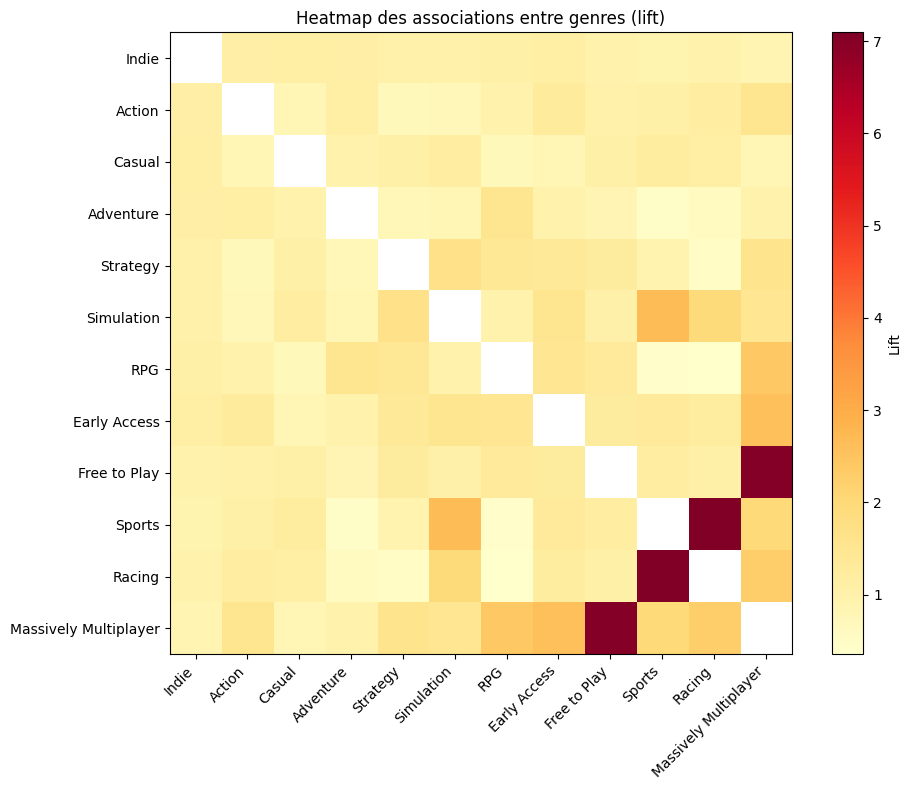

In [0]:
top_n = 12

# Top N genres les plus fréquents
top_genres = (
    df_genres
    .groupBy("genre")
    .agg(F.countDistinct("appid").alias("n_games_genre"))
    .orderBy(F.desc("n_games_genre"))
    .limit(top_n)
)

top_genres_list = [row["genre"] for row in top_genres.collect()]

df_genres_top = df_genres.filter(F.col("genre").isin(top_genres_list))

# Nombre total de jeux
n_games = df_genres.select("appid").distinct().count()

# Fréquence des genres retenus
genre_freq = (
    df_genres_top
    .groupBy("genre")
    .agg(F.countDistinct("appid").alias("n_games_genre"))
)

# Paires de genres
g1 = df_genres_top.alias("g1")
g2 = df_genres_top.alias("g2")

pairs = (
    g1.join(
        g2,
        (F.col("g1.appid") == F.col("g2.appid")) &
        (F.col("g1.genre") < F.col("g2.genre"))
    )
    .groupBy(
        F.col("g1.genre").alias("genre_1"),
        F.col("g2.genre").alias("genre_2")
    )
    .agg(F.countDistinct("g1.appid").alias("n_games_pair"))
)

# Ajout des fréquences individuelles
pairs = (
    pairs
    .join(
        genre_freq.withColumnRenamed("genre", "genre_1")
                  .withColumnRenamed("n_games_genre", "n_genre_1"),
        on="genre_1",
        how="left"
    )
    .join(
        genre_freq.withColumnRenamed("genre", "genre_2")
                  .withColumnRenamed("n_games_genre", "n_genre_2"),
        on="genre_2",
        how="left"
    )
)

# Calcul du lift
pairs = (
    pairs
    .withColumn("p_ab", F.col("n_games_pair") / F.lit(n_games))
    .withColumn("p_a", F.col("n_genre_1") / F.lit(n_games))
    .withColumn("p_b", F.col("n_genre_2") / F.lit(n_games))
    .withColumn("lift", F.col("p_ab") / (F.col("p_a") * F.col("p_b")))
)

display(pairs.orderBy(F.desc("lift")))

# Passage en pandas pour la heatmap
pairs_pd = pairs.select("genre_1", "genre_2", "lift").toPandas()

genres_sorted = top_genres_list
heatmap_df = pd.DataFrame(index=genres_sorted, columns=genres_sorted, data=np.nan)

# Remplissage symétrique
for _, row in pairs_pd.iterrows():
    g1 = row["genre_1"]
    g2 = row["genre_2"]
    val = row["lift"]
    heatmap_df.loc[g1, g2] = val
    heatmap_df.loc[g2, g1] = val

# Diagonale vide
for g in genres_sorted:
    heatmap_df.loc[g, g] = np.nan

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(heatmap_df.values.astype(float),cmap="YlOrRd")

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_xticklabels(heatmap_df.columns, rotation=45, ha="right")
ax.set_yticklabels(heatmap_df.index)

cbar = plt.colorbar(im)
cbar.set_label("Lift")

ax.set_title("Heatmap des associations entre genres (lift)")
plt.tight_layout()
plt.show()

Contrairement à l’analyse des fréquences individuelles, les associations impliquant le genre Indie apparaissent beaucoup moins marquées après correction du biais de fréquence. Sa forte cooccurrence avec d’autres genres reflète principalement sa fréquence élevée plutôt qu’une association spécifique avec certains types de jeux.

La heatmap fait apparaitre différents types de liens entre les genres :

- le genre "Racing" est très fortement associé au genre "sports", ce qui fait apparaitre un lien de thématique. "Racing" est également lié, mais moins fortement, à"Simulation"
- le genre Massively Multiplayer, lui, est très fortement associé au genre "Free to Play", qui fait apparaitre un lien de modèle économique. On retrouve également une association forte (mais moins prononcée que pour "Free to Play") avec le genre "Early Access", également lié au modèle économique des jeux. Enfin, "Massively Multiplayer" est également fortement lié à RPG et, à "Racing".

On voit également que "Simulation" est fortement associé à "Sports" et, dans une moindre mesure, à "Strategy". le genre "RPG", lui, est également assez fortement associé à "Adventure"; Ces liens correspondent plus à des liens de gameplay.

# 4. Structure des prix

On exclue les prix >= 90€ car après analyse, il s'agit majoritairement de placeholders, de logiciels de création ou de jeux VR orientés pros.

### 4.1 Evolution des prix moyens et médians

In [0]:
df_price_year = (
    df
    .select("release_year", "price_eur")
    .filter(
        (F.col("release_year").isNotNull()) &
        (F.col("price_eur").isNotNull()) &
        (F.col("price_eur") < 90) &
        (F.col("release_year") >= 2006)
    )
    .groupBy("release_year")
    .agg(
        F.round(F.avg("price_eur"), 2).alias("avg_price"),
        F.round(F.percentile_approx("price_eur", 0.5), 2).alias("median_price")
    )
    .orderBy("release_year")
)

display(df_price_year)

release_year,avg_price,median_price
2006,9.02,7.99
2007,6.72,4.99
2008,8.53,9.99
2009,9.22,9.99
2010,8.0,6.99
2011,9.07,9.99
2012,9.57,9.99
2013,10.22,9.99
2014,8.94,6.99
2015,7.54,4.99


Databricks visualization. Run in Databricks to view.

### 4.2 Evolution du prix à la sortie des jeux

In [0]:
df_price_classes = (
    df
    .select("appid", "release_year", "initialprice_eur")
    .filter(
        (F.col("release_year").isNotNull()) &
        (F.col("initialprice_eur").isNotNull()) &
        (F.col("release_year") >= 2006) &
        (F.col("initialprice_eur") >= 0) &
        (F.col("initialprice_eur") <= 100)
    )
    .withColumn(
        "price_class",
        F.when(F.col("initialprice_eur") == 0, "Free")
         .when(F.col("initialprice_eur") < 5, "0-5")
         .when(F.col("initialprice_eur") < 10, "5-10")
         .when(F.col("initialprice_eur") < 20, "10-20")
         .when(F.col("initialprice_eur") < 30, "20-30")
         .when(F.col("initialprice_eur") < 40, "30-40")
         .when(F.col("initialprice_eur") < 50, "40-50")
         .when(F.col("initialprice_eur") < 60, "50-60")
         .when(F.col("initialprice_eur") < 70, "60-70")
         .when(F.col("initialprice_eur") < 80, "70-80")
         .when(F.col("initialprice_eur") < 90, "80-90")
         .when(F.col("initialprice_eur") < 100, "90-100")
         .otherwise("100+")
    )
)

window_year = Window.partitionBy("release_year")

df_price_share = (
    df_price_classes
    .groupBy("release_year", "price_class")
    .count()
    .withColumn("total_year", F.sum("count").over(window_year))
    .withColumn("share", (F.round(F.col("count") / F.col("total_year"), 4)))
    .orderBy("release_year", "price_class")
)

display(df_price_share)

release_year,price_class,count,total_year,share
2006,0-5,22,61,0.3607
2006,10-20,9,61,0.1475
2006,20-30,1,61,0.0164
2006,30-40,1,61,0.0164
2006,5-10,23,61,0.377
2006,Free,5,61,0.082
2007,0-5,35,98,0.3571
2007,10-20,13,98,0.1327
2007,20-30,1,98,0.0102
2007,5-10,30,98,0.3061


Databricks visualization. Run in Databricks to view.

On remarque que les jeux vendus sur Steam sont répartis majoritairement entre 4 grandes catégories de prix à leur sortie : "gratuit", "0-5€", "5-10€" et "10-20€" avec une cinquième catégorie qui se développe mais reste très en deça des 4 premières "20-30€".
Cette situation est très cohérente avec la proportion majoritaire de jeux indépendants comparés aux "gros" jeux des studios plus importants

La part des jeux gratuits a cru régulièrement 2009 (7,7%) et 2018 (19,4%), s'est stabilisée entre 2018 et 2020 puis a connu une brusque décroissance de 2021 à 2022 (2,2%).
La part des jeux ayant un prix compris entre 5 et 10€ a régulièrement diminué entre 2011(42,3%) et 2018 (17,94%). elle croit denouveau depuis 2021 et atteint 23,95% en 2022.
La part des jeux dont le prix est compris entre 0 et 5 € croit régulièrement sur la période 2013(22,98%) - 2018 (46,27%). elle baisse en 2019 avant de recroitre légèrement en 2021.


# 5. Les réductions de prix

### 5.1 Proportion de jeux en promotion

In [0]:

df_discount_total = (
    df
    .withColumn(
        "discount_pct",
        F.regexp_extract(F.col("discount"), r"(\d+)", 1).cast("int")
    )
    .withColumn(
        "has_discount",
        F.when(F.col("discount_pct") > 0, 1).otherwise(0)
    )
)

result = (
    df_discount_total
    .agg(
        F.countDistinct("appid").alias("n_games_total"),
        F.sum("has_discount").alias("n_games_discounted")
    )
    .withColumn(
        "discount_share_pct",
        F.round((F.col("n_games_discounted") / F.col("n_games_total")) * 100, 2)
    )
)

display(result)

n_games_total,n_games_discounted,discount_share_pct
55690,2518,4.52


Sur la totalité des jeux présents dans le dataset, la proportion des jeux en réduction au moment de l'extraction est assez faible. Il est toutefois important de noter que cette proportion varie en fonction des opérations promotionnelles organisées par Steam (Steam Sales, etc.)

### 5.2 Promotions selon l’année de sortie

In [0]:
# 1) Nettoyage du discount
df_discount = (
    df.filter((F.col("release_year") >= 2012) & (F.col("release_year") <= 2022))
      .filter(F.col("release_year").isNotNull())
      .withColumn(
          "discount_pct",
          F.regexp_extract(F.col("discount"), r"(\d+)", 1).cast("int")
      )
      .withColumn(
          "has_discount",
          F.when(F.col("discount_pct") > 0, 1).otherwise(0)
      )
)

# 2) Proportion de jeux en réduction par année
df_discount_share = (
    df_discount
    .groupBy("release_year")
    .agg(
        F.countDistinct("appid").alias("n_games_total"),
        F.sum("has_discount").alias("n_games_discounted")
    )
    .withColumn(
        "discount_share_pct",
        F.round((F.col("n_games_discounted") / F.col("n_games_total")) * 100, 2)
    )
    .orderBy("release_year")
)

display(df_discount_share)

release_year,n_games_total,n_games_discounted,discount_share_pct
2012,345,16,4.64
2013,471,25,5.31
2014,1557,83,5.33
2015,2575,108,4.19
2016,4185,171,4.09
2017,6017,198,3.29
2018,7678,293,3.82
2019,6968,292,4.19
2020,8305,325,3.91
2021,8823,453,5.13


Databricks visualization. Run in Databricks to view.


Lorsqu'on regarde le taux de réduction des jeux au moment de l'extraction et en fonction de leur année de sortie, on remarque plusieurs points :

- Globalement, quelle que soit l'année de sortie, le taux de jeux en réduction est faible, oscillant entre 3,3% et 6,9%
- Les jeux sortis récemment par rapport à l'extraction des données sont ceux qui ont la plus forte proportion de jeux en réduction puis viennent les jeux les plus anciens
- il y a une baisse du taux de jeux en réduction dans la période intermédiaire

#### Point d'attention

L'état des réduction de prix sur le catalogue de jeux Steam est à considérer à l'instant de l'extraction des données. Steam a une politique de réduction organisée autour d'évènements périodiques annuels avec des Steam sales à différents moments de l'année.

### 5.3 Analyse du taux de réduction

In [0]:
df_discount_total.select(F.avg("discount_pct")).show()

+------------------+
| avg(discount_pct)|
+------------------+
|2.6038247441192315|
+------------------+



In [0]:
df_discount_total.filter("discount_pct > 0").select(F.avg("discount_pct")).show()

+-----------------+
|avg(discount_pct)|
+-----------------+
|57.58816521048451|
+-----------------+



Le taux de réduction moyen sur la globalité du répertoire Steam est très faible. cependant, si on ramène ce taux à la seule partie des jeux en promotion, il atteint 57,59%, ce qui est important pour une réduction de prix !

#### 5.3.1 Réduction moyenne sur l'ensemble du catalogue, par genre

In [0]:
df_avg_discount_by_genre = (
    df
    .select("appid", "genre", "discount")
    .filter(F.col("genre").isNotNull())
    
    # normaliser les genres
    .withColumn("genre", F.explode(F.split(F.col("genre"), ",")))
    .withColumn("genre", F.trim(F.col("genre")))
    
    # convertir le discount
    .withColumn(
        "discount_pct",
        F.regexp_replace(F.col("discount"), "%", "").cast("double")
    )
    
    # remplacer les nulls par 0 pour inclure les jeux non soldés
    .withColumn(
        "discount_pct_filled",
        F.coalesce(F.col("discount_pct"), F.lit(0))
    )
    
    # calcul par genre
    .groupBy("genre")
    .agg(
        F.countDistinct("appid").alias("n_games"),
        F.round(F.avg("discount_pct_filled"), 2).alias("avg_discount_pct_all_games")
    )
    
    .orderBy(F.desc("avg_discount_pct_all_games"))
)

display(df_avg_discount_by_genre.limit(20))

genre,n_games,avg_discount_pct_all_games
Violent,168,3.84
Gore,99,3.59
Adventure,21431,3.12
Nudity,45,3.11
Sports,2666,3.06
Casual,22086,2.98
Racing,2155,2.96
Simulation,10836,2.83
RPG,9534,2.83
Indie,39681,2.77


Databricks visualization. Run in Databricks to view.

#### 5.3.2 Réduction moyenne uniquement pour les jeux bénéficiant d'une réduction, par genre

In [0]:
df_genres_discount = (
    df
    .select("appid", "genre", "discount", "initialprice_eur")
    .filter(F.col("genre").isNotNull())
    .withColumn("genre", F.explode(F.split(F.col("genre"), ",")))
    .withColumn("genre", F.trim(F.col("genre")))
    .withColumn(
        "discount_pct",
        F.regexp_replace(F.col("discount"), "%", "").cast("double")
    )
)

df_avg_discount_sold_only = (
    df_genres_discount
    .filter(F.col("initialprice_eur") > 0)
    .filter(F.col("initialprice_eur") <90)
    .filter(F.col("genre") != "Free to Play")
    .filter(F.col("discount_pct") > 0)
    .groupBy("genre")
    .agg(
        F.countDistinct("appid").alias("n_discounted_games"),
        F.round(F.avg("discount_pct"), 2).alias("avg_discount_pct_discounted_only")
    )
    # .filter(F.col("n_discounted_games") >= 20)
    .orderBy(
        F.desc("avg_discount_pct_discounted_only"),
        F.desc("n_discounted_games")
    )
)

display(df_avg_discount_sold_only.limit(20))

genre,n_discounted_games,avg_discount_pct_discounted_only
Gore,4,88.75
Violent,9,71.67
Nudity,2,70.0
Education,6,68.33
Massively Multiplayer,38,65.58
,2,65.0
Sexual Content,2,65.0
Racing,105,60.82
Software Training,4,60.0
Action,1042,58.64


Databricks visualization. Run in Databricks to view.

Les genres de jeux les plus fortement soldés au moment de l'extraction des données sont les genres "gores", "violent" (souvent associés l'un et l'autre pour un même jeu), "nudity", "sexual content" (souvent associés l'un et l'autre pour un même jeu), "Education" ou "Massively Multiplayer". ce dernier genre est intéressant car il contient des jeux qui peuvent fonctionner avec abonnement ==> la promotion réalisée sur la vente du jeu peut donc permettre de favoriser la contractualisation d'un abonnement mensuel par la suite.

# 6. Restrictions d'âge

### 6.1 Distribution des âges requis

In [0]:
df_age_distribution = (
    df
    .filter(F.col("required_age_num").isNotNull())
    .groupBy("required_age_num")
    .count()
)

total_games = df_age_distribution.agg(F.sum("count")).collect()[0][0]

df_age_distribution = (
    df_age_distribution
    .withColumn(
        "share_pct",
        F.round((F.col("count") / total_games) * 100, 2)
    )
    .orderBy("required_age_num")
)

display(df_age_distribution)

required_age_num,count,share_pct
0,55029,98.81
3,3,0.01
5,1,0.0
6,4,0.01
7,3,0.01
8,3,0.01
9,1,0.0
10,7,0.01
12,32,0.06
13,26,0.05


In [0]:

df_age_zero = (
    df
    .agg(
        F.countDistinct("appid").alias("total_games"),
        F.sum(F.when(F.col("required_age_num") == 0, 1).otherwise(0)).alias("no_age_limit")
    )
    .withColumn(
        "share_no_limit_pct",
        F.round(F.col("no_age_limit") / F.col("total_games") * 100, 2)
    )
)

display(df_age_zero)

total_games,no_age_limit,share_no_limit_pct
55690,55029,98.81


Sur 55 690 jeux présents dans le dataset, seuls 661 ont une restriction d'âge indiquée. Cela pose tout de suite la question de la pertinence de l'analyse de la variable "required_age".

### 6.2 Restriction d'âge par genre, pour les jeux ayant une restriction d'âge explicitement renseignée

In [0]:
df_age_restricted = (
    df
    .filter(F.col("required_age_num") > 0)
    .withColumn(
        "age_class",
        F.when(F.col("required_age_num") >= 18, "18+")
         .otherwise(F.col("required_age_num").cast("string"))
    )
)

df_age_dist = (
    df_age_restricted
    .groupBy("age_class")
    .agg(F.countDistinct("appid").alias("n_games"))
)

total_restricted = (
    df_age_restricted
    .select(F.countDistinct("appid").alias("total"))
    .first()["total"]
)

df_age_dist = (
    df_age_dist
    .withColumn(
        "share_pct",
        F.round(F.col("n_games") / F.lit(total_restricted) * 100, 2)
    )
)

df_age_dist = (
    df_age_dist
    .withColumn(
        "sort_order",
        F.when(F.col("age_class") == "18+", 18)
         .otherwise(F.col("age_class").cast("int"))
    )
    .orderBy("sort_order")
    .select("age_class", "share_pct")
)

display(df_age_dist)

age_class,share_pct
3,0.45
5,0.15
6,0.61
7,0.45
8,0.45
9,0.15
10,1.06
12,4.84
13,3.93
14,1.51


Databricks visualization. Run in Databricks to view.

Parmis les 661 jeux ayant une restriction d'âge indiquée, 86,4% des jeux ont une restriction d'âge >= 15 ans (dont 34,8% >= 18 ans)

#### 6.2.1 Ventilation de la proportion de jeux avec une restriction d'âge signalée par genre

In [0]:
df_genres_age = (
    df
    .withColumn("genre", F.explode(F.split(F.col("genre"), ",")))
    .withColumn("genre", F.trim(F.col("genre")))
    .filter(F.col("genre") != "")
)

df_genres_age = df_genres_age.withColumn(
    "has_age_limit",
    F.when(F.col("required_age_num") > 0, "Age limit")
     .otherwise("No age limit")
)

df_age_by_genre = (
    df_genres_age
    .filter(F.col("genre")!="Movie")
    .groupBy("genre" )
    .agg(
        F.countDistinct("appid").alias("n_games"),
        F.countDistinct(
            F.when(F.col("required_age_num") > 0, F.col("appid"))
        ).alias("n_with_limit")
    )
    .withColumn(
        "share_with_limit_pct",
        F.round(F.col("n_with_limit") / F.col("n_games") * 100, 2)
    )
    .withColumn(
        "share_without_limit_pct",
        F.round(100 - F.col("share_with_limit_pct"), 2)
    )
    .orderBy(F.desc("share_with_limit_pct"))
)

display(df_age_by_genre)

genre,n_games,n_with_limit,share_with_limit_pct,share_without_limit_pct
Gore,99,6,6.06,93.94
Sexual Content,54,3,5.56,94.44
Nudity,45,2,4.44,95.56
Violent,168,7,4.17,95.83
Massively Multiplayer,1460,28,1.92,98.08
Action,23759,425,1.79,98.21
RPG,9534,147,1.54,98.46
Adventure,21431,313,1.46,98.54
Free to Play,3393,42,1.24,98.76
Early Access,6145,47,0.76,99.24


Databricks visualization. Run in Databricks to view.

La proportion de jeux ayant une restriction d'âge explicite selon les genres rattachés parait surprenante, notamment pour des genres de type "gore", "sexual content", "nudity" ou "violent".

Il n’existe pas, dans la plupart des juridictions, d’obligation légale générale imposant aux éditeurs de jeux vidéo d’afficher une classification d’âge telle que PEGI ou ESRB. Ces systèmes sont des dispositifs d’autorégulation de l’industrie. En revanche, certaines législations interdisent la vente ou la mise à disposition de contenus particulièrement explicites aux mineurs. Sur des plateformes comme Steam, les éditeurs ne sont donc pas systématiquement contraints d’indiquer une restriction d’âge. En conséquence, dans notre dataset, la variable "required_age" est très peu renseignée.



### 6.3 Analyse du catalogue de jeux adultes

In [0]:
df_age = (
    df
    .withColumn(
        "age_class",
        F.when(F.col("required_age_num").isNull(), "Unknown")
         .when(F.col("required_age_num") > 18, "18+")
         .otherwise(F.col("required_age_num").cast("string"))
    )
)

df_adult_weight = (
    df_age
    .withColumn(
        "adult_class",
        F.when(F.col("required_age_num") >= 18, "18+")
         .otherwise("Non 18+")
    )
    .groupBy("adult_class")
    .agg(F.countDistinct("appid").alias("n_games"))
)

df_adult_weight = (
    df_adult_weight
    .withColumn("share_pct", F.round((F.col("n_games") / F.lit(total_games)) * 100, 2))
)

display(df_adult_weight)

adult_class,n_games,share_pct
18+,230,0.41
Non 18+,55460,99.59


Sur l'ensemble du dataset, les jeux réservés explicitement aux plus de 18 ans représentent 0,41% du total des jeux.

#### 6.3.1 Jeux réservés explicitement aux plus de 18 ans par genre

In [0]:
# Jeux 18+ par genre
df_genres_18 = (
    df
    .filter(F.col("required_age_num").isNotNull())
    .withColumn("genre", F.explode(F.split(F.col("genre"), ",")))
    .withColumn("genre", F.trim(F.col("genre")))
    .filter(F.col("genre") != "")
)

df_adult_by_genre = (
    df_genres_18
    .groupBy("genre")
    .agg(
        F.countDistinct("appid").alias("n_games"),
        F.countDistinct(
            F.when(F.col("required_age_num") >= 18, F.col("appid"))
        ).alias("n_games_18plus")
    )
    .withColumn(
        "share_18plus_pct",
        F.round((F.col("n_games_18plus") / F.col("n_games")) * 100, 2)
    )
    .orderBy(F.desc("share_18plus_pct"))
)

display(df_adult_by_genre)

genre,n_games,n_games_18plus,share_18plus_pct
Sexual Content,54,3,5.56
Nudity,45,2,4.44
Gore,99,3,3.03
Violent,168,3,1.79
Action,23759,130,0.55
RPG,9534,52,0.55
Adventure,21431,109,0.51
Simulation,10836,47,0.43
Massively Multiplayer,1460,6,0.41
Early Access,6145,21,0.34


Databricks visualization. Run in Databricks to view.

Les taux sont très très faibles. Il faut garder en tête que seuls 1,2% des jeux ont une restriction d'âge explicitement indiquée dans "required_age"

#### 6.3.2 Jeux réservés explicitement aux plus de 18 ans par genre uniquement pour les jeux ayant une limite d'âge signalée

In [0]:
df_genres_age = (
    df
    # garder uniquement les jeux avec classification d'âge
    .filter(F.col("required_age_num") > 0)
    
    # exploser les genres
    .withColumn("genre", F.explode(F.split(F.col("genre"), ",")))
    .withColumn("genre", F.trim(F.col("genre")))
    .filter(F.col("genre") != "")
)

df_adult_by_genre = (
    df_genres_age
    .groupBy("genre")
    .agg(
        F.countDistinct("appid").alias("n_games_classified"),
        F.countDistinct(
            F.when(F.col("required_age_num") >= 18, F.col("appid"))
        ).alias("n_games_18plus")
    )
    .withColumn(
        "share_18plus_pct",
        F.round(
            F.col("n_games_18plus") / F.col("n_games_classified") * 100,
            2
        )
    )
    .orderBy(F.desc("share_18plus_pct"))
)

display(df_adult_by_genre)

genre,n_games_classified,n_games_18plus,share_18plus_pct
Sexual Content,3,3,100.0
Nudity,2,2,100.0
Simulation,77,47,61.04
Sports,8,4,50.0
Gore,6,3,50.0
Indie,280,127,45.36
Early Access,47,21,44.68
Violent,7,3,42.86
Casual,93,39,41.94
RPG,147,52,35.37


Databricks visualization. Run in Databricks to view.

Si on analyse les 230 jeux ayant une restriction d'âge explicite 18+, on retrouve sans surprise les genres "sexual content", "nudity" avec 100% des jeux ayant une restriction d'âge indiquée étant réservés au 18+, 50% des jeux ayant le genre "gore" rattaché réservés au 18+ et 42,86% des jeux ayant le genre "violent" rattaché.

De manière plus surprenante, on retrouve des jeux ayant des genres comme "Sports" ou "Racing".

Pour finir sur les restrictions d'âge, la variable "required_age" est peu exploitable pour l’analyse car elle est renseignée pour une très faible proportion des jeux (≈ 1,2 %). Elle ne constitue donc pas un indicateur fiable de la présence de contenu mature dans le catalogue Steam. De même, cette observation ne permet pas de conclure à un manquement de la plateforme en matière de protection des mineurs, celle-ci pouvant reposer sur d'autres mécanismes tels que avertissements de contenu, barrières d'âge pour certaines pages, filtres de contenus dans le compte utilisateur, etc.

# 7. Reviews et popularité

### 7.1 Popularité des jeux par tranches de volume de reviews

afin d'éviter un biais lié aux jeux ayant peu de reviews mais dont toutes les reviews sont à 100%, ce qui est impossible pour les jeux ayant beaucoup de reviews.

In [0]:

df_reviews_bins = (
    df
    .filter(F.col("reviews_total") >= 100)
    .withColumn(
        "reviews_bin",
        F.when(F.col("reviews_total") < 500, "100-500")
        .when(F.col("reviews_total") < 2000, "500-2k")
        .when(F.col("reviews_total") < 5000, "2k-5k")
        .when(F.col("reviews_total") < 10000, "5k-10k")
        .when(F.col("reviews_total") < 50000, "10k-50k")
        .when(F.col("reviews_total") < 100000, "50k-100k")
        .when(F.col("reviews_total") < 200000, "100k-200k")
        .when(F.col("reviews_total") < 1000000, "200k-1M")
        .otherwise("1M+")
    )
)

w = Window.partitionBy("reviews_bin").orderBy(
    F.desc("steam_score"),
    F.desc("reviews_total")
)

df_top_reviews_bins = (
    df_reviews_bins
    .withColumn("rank", F.row_number().over(w))
    .filter(F.col("rank") <= 10)
    .select(
        "reviews_bin",
        "name",
        "steam_score",
        "reviews_total",
        "rank"
    )
    .orderBy("reviews_bin","rank")
)

display(df_top_reviews_bins)

reviews_bin,name,steam_score,reviews_total,rank
100-500,The Void Rains Upon Her Heart,100.0,496,1
100-500,祈風 Inorikaze,100.0,327,2
100-500,秘封旅行 ~ Secret Sealing Travel,100.0,218,3
100-500,Elasto Mania Remastered,100.0,190,4
100-500,Freshly Frosted,100.0,157,5
100-500,HAYAI,100.0,148,6
100-500,FIND ALL 2: Middle Ages,100.0,132,7
100-500,Touhou Kaeizuka ～ Phantasmagoria of Flower View.,100.0,119,8
100-500,Lucy Dreaming,100.0,118,9
100-500,未来战士,100.0,116,10


Databricks visualization. Run in Databricks to view.

Pour les plus petites sorties, ayant un petit nombre de reviews, les scores peuvent facilement atteindre 100%. C'est ce que nous constatons ici, pour les jeux appartenant à la classe 100-500.

A partir de 500-2 000 reviews il y a plus de chances d'avoir des reviews négatives, ce qui limite la possibilité d'atteindre 100%.

En terme de lien entre nombre de reviews et succès commercial des jeux, typiquement, dans l'industrie du jeu vidéo on considère :

- moins de 500 reviews : sortie confidentielle
- 500 - 2 000 reviews : jeu émergent
- 2 000 - 5 000 : succès
- 5 000 - 10 000 reviews : gros succès
- 10 000 - 50 000 reviews : hit
- 50 000 - 100 000 reviews : gros hit
- 100 000 - 200 000 reviews : méga hit
- 200 000 - 1 000 000 reviews : phénomène
- \>1 000 000 reviews : Licorne

# 8. Analyse combinée

### 8.1 Nombre de reviews * score * prix

In [0]:
df_price_score = (
    df
    .filter(F.col("price_eur").isNotNull())
    .filter(F.col("steam_score").isNotNull())
    .filter(F.col("reviews_total") >= 100)
    .filter(F.col("price_eur") >= 0)
    .filter(F.col("price_eur") < 90)   # optionnel pour enlever les gros outliers
    .select(
        "appid",
        "name",
        "price_eur",
        "steam_score",
        "reviews_total",
        "owners_avg",
        "release_year",
        "genre"
    )
)

display(df_price_score)

appid,name,price_eur,steam_score,reviews_total,owners_avg,release_year,genre
10,Counter-Strike,9.99,97.48127549487923,206414,1.5E7,2000,Action
1000010,Crown Trick,5.99,86.19067977768276,4678,350000.0,2020,"Adventure, Indie, RPG, Strategy"
1000030,"Cook, Serve, Delicious! 3?!",19.99,93.19526627218934,1690,150000.0,2020,"Action, Indie, Simulation, Strategy"
1000080,Zengeon,7.99,68.78378378378378,1480,150000.0,2019,"Action, Adventure, Indie, RPG"
1000360,Hellish Quart,16.99,92.75195582144501,4346,350000.0,2021,"Action, Early Access"
1000380,Rogue Reaper,0.0,78.03030303030303,396,150000.0,2019,"Action, Adventure, Free to Play, Indie"
1000410,WRATH: Aeon of Ruin,24.99,78.70129870129871,1540,35000.0,2019,"Action, Early Access"
1000510,The Marvellous Machine,0.0,83.2,125,35000.0,2019,Education
1000640,Clam Man,9.99,93.04347826086956,115,10000.0,2019,"Adventure, Indie"
1000830,Gachi Finder 3000,0.99,97.59036144578313,166,10000.0,2019,"Casual, Indie, Strategy"


Databricks visualization. Run in Databricks to view.

Ce graphique permet, en fonction du prix, d'identifier les jeux ayant été beaucoup commentés (aire des bulles) et de situer leur score. Attention : pour les jeux les plus récents il peut y avoir un biais lié à la faible ancienneté sur la plateforme et donc à un relativement faible volume de reviews par rapport à ce qu'il pourraient avoir à maturité.

Ce graphique permet d'identifier aisément les jeux les mieux notés avec un fort engagement des joueurs par niveau de prix. De même, on repère plus aisément les jeux ayant entrainé un grand nombre de réactions des joueurs mais ayant été mal notés (campagnes de bashing, trolling ou réel échec qualitatif).

Enfin, ce graphique fait ressortir les différents types de jeux du marché Steam ==> On remarque, sur la gauche du graphique une très large majorité de jeux indépendants gratuis ou à faible prix puis, plus on se déplace vers la droite du graphique (plus le prix croit), plus on trouve des studios importants et des jeux AA et AAA mais en quantités moindres.

### 8.2 Score * genre

In [0]:
df_genres = (
    df
    .withColumn("genre", F.explode(F.split(F.col("genre"), ",")))
    .withColumn("genre", F.trim("genre"))
)

top_genres = (
    df_genres
    .groupBy("genre")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)
)

df_genres_top = df_genres.join(top_genres.select("genre"), "genre")


w = Window.partitionBy("genre").orderBy(F.desc("steam_score"), F.desc("reviews_total"))

MIN_REVIEWS = 500

df_top10_genres = (
    df_genres_top
    .filter(F.col("reviews_total") >= MIN_REVIEWS)
    .withColumn("rank", F.row_number().over(w))
    .filter(F.col("rank") <= 10)
    .select("genre","name","steam_score","reviews_total","rank")
    .orderBy("genre","rank")
)

display(df_top10_genres)


genre,name,steam_score,reviews_total,rank
Action,Touhou Fuujinroku ~ Mountain of Faith.,99.3874425727412,653,1
Action,CULTIC,99.21453117329406,2037,2
Action,ARMORED HEAD,99.19786096256684,748,3
Action,It Steals,99.05511811023622,635,4
Action,People Playground,98.85936819096763,144569,5
Action,Tinykin,98.80059970014993,667,6
Action,Portal 2,98.78167405094995,309441,7
Action,Vampire Survivors,98.76909084018646,131935,8
Action,Batman: Arkham City,98.70259481037924,2004,9
Action,ULTRAKILL,98.65017981181339,40598,10


Databricks visualization. Run in Databricks to view.

Attention : ce graphique peut présenter le même jeu dans plusieurs genres. En effet, plusieurs genres peuvent être rattachés à un jeu et donc, si ce dernier est particulièrement bien noté, il pourra apparaitre dans le top 10 des jeux pour plusieurs genres. C'est le cas, par exemple, pour "Vampire Survivors" qui apparait dans les genres "Action" et "RPG".

Quel que soit le genre, ce sont les jeux indépendants qui sont les plus représentés, même dans les meilleurs scores. Seuls "Portal 2" et "Batman: Arkham City" sont produits par de gros éditeurs

### 8.3 Score*Nombre de reviews

In [0]:


MIN_REVIEWS = 500


df = df.withColumn(
    "score_weighted",
    F.round(F.col("pos_ratio") * F.log10(F.col("reviews_total")+1) * 100,2)
)

w_year = Window.partitionBy("release_year").orderBy(F.desc("score_weighted"), F.desc("reviews_total"))
df_best_per_year = (
    df
    .filter(F.col("release_year").isNotNull())
    .filter(F.col("reviews_total") >= MIN_REVIEWS)
    .withColumn("rank", F.row_number().over(w_year))
    .filter(F.col("rank") == 1)
    .select("release_year","name","score_weighted","reviews_total")
    .orderBy("release_year")
)

display(df_best_per_year)

release_year,name,score_weighted,reviews_total
1997,POSTAL,329.71,5916
1998,Half-Life,472.74,78577
1999,Half-Life: Opposing Force,399.16,15643
2000,Counter-Strike,518.09,206414
2001,Half-Life: Blue Shift,371.49,11629
2002,Mafia,348.68,10111
2003,Day of Defeat,339.69,5820
2004,Half-Life 2,504.6,150137
2005,Half-Life 2: Lost Coast,356.14,10842
2006,Garry's Mod,574.97,891238


Databricks visualization. Run in Databricks to view.

Afin d’éviter de surévaluer les jeux ayant très peu de reviews, un score pondéré par le volume de reviews a été utilisé. Ce score permet d’identifier les jeux combinant à la fois une excellente appréciation par les joueurs et un large volume d’avis.

Ici, pour l'année 2001, c'est le jeu Half-Life : Blue Shift qui est le jeu ayant le score pondéré du volume total de reviews le plus élevé parmis l'ensemble des jeux sortis cette même année.

Pour l'année 2012, il s'agit de Counter-Strike : Global Offensive et pour 2022 il s'agit d'Elden Ring.

### 8.4 Catégorie*score

In [0]:

# 1. Définir les jeux populaires (reviews + score)
popular_games = (
    df
    .filter(
        (F.col("reviews_total") >= 20000) &
        (F.col("steam_score") >= 95)
    )
    .select("appid")
    .distinct()
)

# 2. Liste des catégories gameplay pertinentes
gameplay_categories = [
    "Single-player",
    "Multi-player",
    "Co-op",
    "Online Co-op",
    "PvP",
    "Online PvP",
    "Cross-Platform Multiplayer",
    "Shared/Split Screen",
    "Shared/Split Screen Co-op",
    "LAN Co-op",
    "LAN PvP"
]

# 3. Filtrer df_categories sur ces catégories
df_gameplay_categories = (
    df_categories
    .filter(F.col("category").isin(gameplay_categories))
)

# 4. Taille des populations
total_games = (
    df_gameplay_categories
    .select("appid")
    .distinct()
    .count()
)

total_popular_games = (
    df_gameplay_categories
    .join(popular_games, "appid")
    .select("appid")
    .distinct()
    .count()
)

# 5. Part des catégories dans le catalogue global
global_category_share = (
    df_gameplay_categories
    .groupBy("category")
    .agg(F.countDistinct("appid").alias("global_games"))
    .withColumn(
        "global_share",
        F.col("global_games") / F.lit(total_games)
    )
)

# 6. Part des catégories dans les jeux populaires
popular_category_share = (
    df_gameplay_categories
    .join(popular_games, "appid")
    .groupBy("category")
    .agg(F.countDistinct("appid").alias("popular_games"))
    .withColumn(
        "popular_share",
        F.col("popular_games") / F.lit(total_popular_games)
    )
)

# 7. Comparaison des distributions
gameplay_overrepresentation = (
    global_category_share
    .join(popular_category_share, "category", "left")
    .fillna(0)
    .withColumn(
        "overrepresentation_ratio",
        F.when(
            F.col("global_share") > 0,
            F.col("popular_share") / F.col("global_share")
        )
    )
    .withColumn(
        "lift",
        (F.col("popular_share") - F.col("global_share")) * 100
    )
    .orderBy(F.desc("lift"))
)

display(gameplay_overrepresentation)

category,global_games,global_share,popular_games,popular_share,overrepresentation_ratio,lift
Multi-player,11455,0.2105040704191705,55,0.3691275167785235,1.7535409934995123,15.862344635935303
Co-op,5616,0.10320304316665747,38,0.2550335570469799,2.471182527390581,15.183051388032244
Online Co-op,2981,0.0547806751566606,30,0.20134228187919462,3.675425344857475,14.656160672253401
Online PvP,5025,0.09234246650862782,23,0.15436241610738255,1.6716297706100371,6.201994959875473
Shared/Split Screen Co-op,2450,0.04502269511365933,14,0.09395973154362416,2.0869415148609782,4.893703642996483
Cross-Platform Multiplayer,1742,0.03201205505632431,10,0.06711409395973154,2.0965256320359997,3.510203890340723
LAN Co-op,409,0.007516033592443538,6,0.040268456375838924,5.357673815657767,3.2752422783395385
LAN PvP,474,0.008710513258724295,5,0.03355704697986577,3.852476425112565,2.4846533721141477
PvP,7070,0.1299226344708455,23,0.15436241610738255,1.1881102683614477,2.443978163653704
Shared/Split Screen,4324,0.0794604627230461,15,0.10067114093959731,1.2669337364731885,2.1210678216551204


Databricks visualization. Run in Databricks to view.

D'après le graphique ci-dessus, on remarque que les jeux les plus populaires proposent beaucoup plus fréquemment un mode Multi-player et en particulier un Multi-player en coopération.

On remarque que les modes cross-platform et local multiplayer (au travers de "Shared/Split Screen") sont également sur représentés. Cela suggère que la fléxibilité du multi joueur peut contribuer à l'adoption massive par les joueurs.

Il est toutefois nécessaire de nuancer cette analyse :

Les jeux multi-joueurs sont souvent plus ambitieux et développés par de plus grandes équipes et le multi joueur peut être plutôt un symptôme du succès qu'une cause.

# 9. Limites de l'analyse

Plusieurs limites doivent être prises en compte, dans l'interprétation des résultats présentés :

- Les données correspondent à une photographie du catalogue Steam à un instant donné. Les variables liées aux prix, évaluations, promotions peuvent évoluer dans le temps. les analyses réalisées ne sont donc valables qu'au moment de l'extraction et ne permettent pas d'observer les dynamiques temporelles.

- Les genres ne sont pas exclusifs : un même jeu peut avoir plusieurs genres qui lui sont associés. Cette caractéristique peut rendre certaines interprétations délicates.

- Le nombre de reviews ne représentent pas une évaluation parfaite de la popularité d'un jeu. Elles reflètent l'engagement des joueurs ayant choisi de laisser une évaluation et ne correspondent pas directement au nombre d'unités vendues.

-  Les promotions observées sont ponctuelles et dépendent fortement du calendrier commercial de Steam. La présence ou l'absence d'une promotion au moment de l'extraction ne permet donc pas d'inférer une stratégie commerciale stable.